### Download 'Chest X-Ray Images (Pneumonia)' Dataset from Kaggle

First, we need to install the Kaggle library and set up credentials. Please make sure you have uploaded your `kaggle.json` file (containing your API key) to your Colab environment, for example, by dragging it into the files pane on the left, or using `files.upload()`.

In [ ]:
import os
from google.colab import files

# Install Kaggle library
!pip install -q kaggle

# Ensure the .kaggle directory exists
!mkdir -p ~/.kaggle

# Move the uploaded kaggle.json file to the correct location
# Assumes kaggle.json is uploaded to /content/
# If you manually uploaded it to a different path, please adjust this line
!mv /content/kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key setup complete.")

mv: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key setup complete.


Now, let's download the 'Chest X-Ray Images (Pneumonia)' dataset. This dataset is suitable for image classification tasks related to health, aligning with your interests in CNNs and computer vision.

In [ ]:
# Download the dataset from Kaggle
# The dataset ID for 'Chest X-Ray Images (Pneumonia)' is 'paultimothymooney/chest-xray-pneumonia'
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/dataset

# Unzip the downloaded dataset
import zipfile
import os

zip_path = '/content/dataset/chest-xray-pneumonia.zip'
extract_path = '/content/dataset/chest_xray_images'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset downloaded to {zip_path} and extracted to {extract_path}")

# Verify the directory structure (optional)
print("\nDataset directory structure:")
!ls -R /content/dataset/chest_xray_images

Streaming output truncated to the last 5000 lines.
NORMAL2-IM-0388-0001.jpeg	NORMAL2-IM-1293-0001.jpeg
NORMAL2-IM-0389-0001.jpeg	NORMAL2-IM-1294-0001-0001.jpeg
NORMAL2-IM-0390-0001.jpeg	NORMAL2-IM-1294-0001-0002.jpeg
NORMAL2-IM-0391-0001.jpeg	NORMAL2-IM-1294-0001.jpeg
NORMAL2-IM-0392-0001.jpeg	NORMAL2-IM-1295-0001.jpeg
NORMAL2-IM-0393-0001.jpeg	NORMAL2-IM-1296-0001.jpeg
NORMAL2-IM-0394-0001.jpeg	NORMAL2-IM-1300-0001.jpeg
NORMAL2-IM-0395-0001-0001.jpeg	NORMAL2-IM-1301-0001.jpeg
NORMAL2-IM-0395-0001-0002.jpeg	NORMAL2-IM-1302-0001.jpeg
NORMAL2-IM-0395-0001.jpeg	NORMAL2-IM-1303-0001.jpeg
NORMAL2-IM-0396-0001.jpeg	NORMAL2-IM-1304-0001.jpeg
NORMAL2-IM-0397-0001.jpeg	NORMAL2-IM-1305-0001.jpeg
NORMAL2-IM-0399-0001.jpeg	NORMAL2-IM-1306-0001.jpeg
NORMAL2-IM-0401-0001.jpeg	NORMAL2-IM-1307-0001.jpeg
NORMAL2-IM-0402-0001.jpeg	NORMAL2-IM-1308-0001.jpeg
NORMAL2-IM-0403-0001.jpeg	NORMAL2-IM-1310-0001.jpeg
NORMAL2-IM-0404-0001.jpeg	NORMAL2-IM-1311-0001.jpeg
NORMAL2-IM-0406-0001.jpeg	NORMAL2-IM-1314-000

### Data Preprocessing and Augmentation

We'll use Keras's `ImageDataGenerator` to handle image loading, resizing, and augmentation. This is crucial for improving model generalization and preventing overfitting, especially with medical image datasets.

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define paths to the dataset directories
base_dir = '/content/dataset/chest_xray_images/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Image dimensions and batch size
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Data Augmentation and Rescaling for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values to [0, 1]
    rotation_range=20,          # Random rotation up to 20 degrees
    width_shift_range=0.1,      # Random horizontal shift
    height_shift_range=0.1,     # Random vertical shift
    shear_range=0.1,            # Shear transformations
    zoom_range=0.1,             # Random zoom
    horizontal_flip=True,       # Random horizontal flip
    fill_mode='nearest'         # Strategy for filling in new pixels after transformations
)

# Rescaling for Validation and Test Data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary' # Since we have two classes (NORMAL, PNEUMONIA)
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, # Use batch_size=1 for test generator to make prediction easier
    class_mode='binary',
    shuffle=False # Keep data in order for evaluation
)

print("\nData generators successfully set up.")
print(f"Training images found: {train_generator.samples}")
print(f"Validation images found: {validation_generator.samples}")
print(f"Test images found: {test_generator.samples}")

# Display class indices (0 and 1 for 'NORMAL' and 'PNEUMONIA')
print("\nClass indices:")
print(train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Data generators successfully set up.
Training images found: 5216
Validation images found: 16
Test images found: 624

Class indices:
{'NORMAL': 0, 'PNEUMONIA': 1}


### Visualize Augmented Training Images

Let's display a batch of augmented training images to see the effects of our `ImageDataGenerator`.

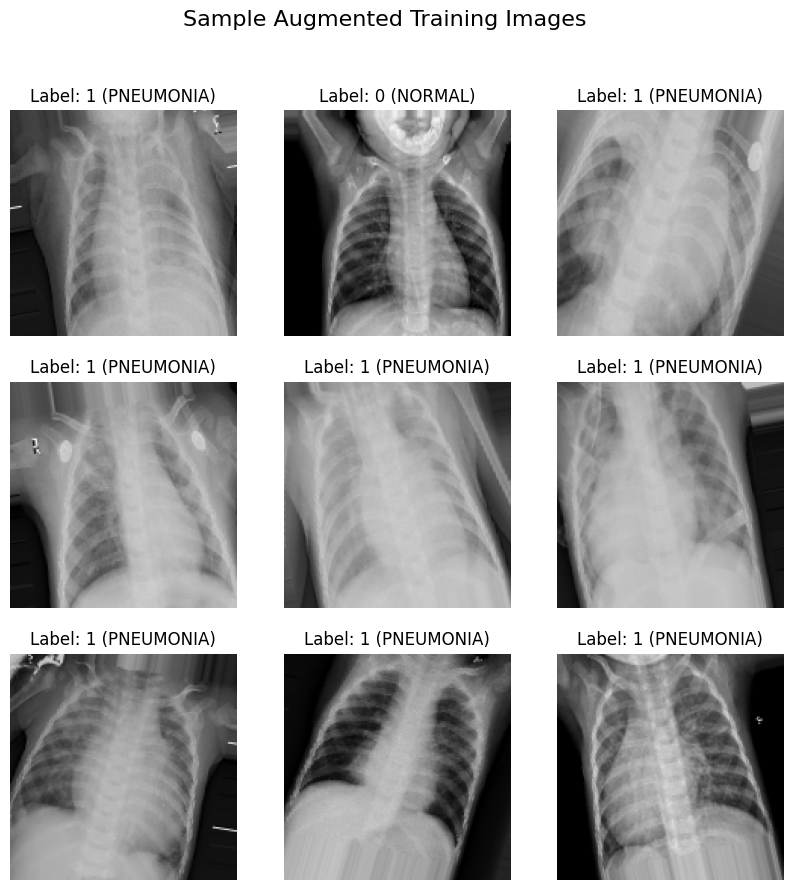

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of training images and labels
images, labels = next(train_generator)

# Create a figure and a grid of subplots
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])} ({'PNEUMONIA' if labels[i] else 'NORMAL'})")
    plt.axis("off")
plt.suptitle("Sample Augmented Training Images", fontsize=16)
plt.show()

### Build the Convolutional Neural Network (CNN) Model

Now, we'll define the architecture of our CNN model using TensorFlow and Keras. We'll use a sequential model, stacking convolutional layers, pooling layers, and dense layers for classification.

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5), # Add dropout for regularization to prevent overfitting
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("CNN model built and compiled successfully!")

CNN model built and compiled successfully!


### Computer Vision

This entire project is an application of **Computer Vision**. Specifically, we are building a system to visually analyze medical images (X-rays) to detect a condition (pneumonia). The `ImageDataGenerator` and the CNN model are core components enabling the computer to 'see' and interpret these images.

### Image Processing

**Image Processing** is handled by the `ImageDataGenerator` which not only rescales pixel values but also applies various augmentations like rotation, shifts, and zooms. This helps in making the model robust to variations in image capture.

Here's a reminder of the image processing (and augmentation) parameters used:

In [16]:
print("Training Data Augmentation Parameters:")
print(f"  Rescale: {train_datagen.rescale}")
print(f"  Rotation Range: {train_datagen.rotation_range}")
print(f"  Width Shift Range: {train_datagen.width_shift_range}")
print(f"  Height Shift Range: {train_datagen.height_shift_range}")
print(f"  Shear Range: {train_datagen.shear_range}")
print(f"  Zoom Range: {train_datagen.zoom_range}")
print(f"  Horizontal Flip: {train_datagen.horizontal_flip}")
print(f"  Fill Mode: {train_datagen.fill_mode}")

print("\nValidation and Test Data Rescaling:")
print(f"  Rescale: {val_datagen.rescale}")

Training Data Augmentation Parameters:
  Rescale: 0.00392156862745098
  Rotation Range: 20
  Width Shift Range: 0.1
  Height Shift Range: 0.1
  Shear Range: 0.1
  Zoom Range: [0.9, 1.1]
  Horizontal Flip: True
  Fill Mode: nearest

Validation and Test Data Rescaling:
  Rescale: 0.00392156862745098


### Image Classification

The goal of this task is **Image Classification**, specifically binary classification to distinguish between 'NORMAL' and 'PNEUMONIA' X-ray images. The `class_mode='binary'` in the `flow_from_directory` function and the sigmoid activation in the final layer of the CNN confirm this.

Here are the class indices established by the data generators:

In [18]:
print("Class Indices for Image Classification:")
print(train_generator.class_indices)
print("\nThis means 'NORMAL' images are classified as 0 and 'PNEUMONIA' images as 1.")

Class Indices for Image Classification:
{'NORMAL': 0, 'PNEUMONIA': 1}

This means 'NORMAL' images are classified as 0 and 'PNEUMONIA' images as 1.


### CNN (Convolutional Neural Network)

The core of the image classification model is a **Convolutional Neural Network**. Its architecture, including convolutional layers for feature extraction and pooling layers for down-sampling, was defined and compiled.

Here's the summary of the CNN model we built:

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

### For RNN (Recurrent Neural Network): Time Series Forecasting
For RNNs, especially for a quick demonstration, we'll generate a simple synthetic time series dataset. This allows us to easily control its sequential nature and observe the RNN's ability to learn patterns over time.

First, I will generate a sine wave time series and prepare it for RNN input.

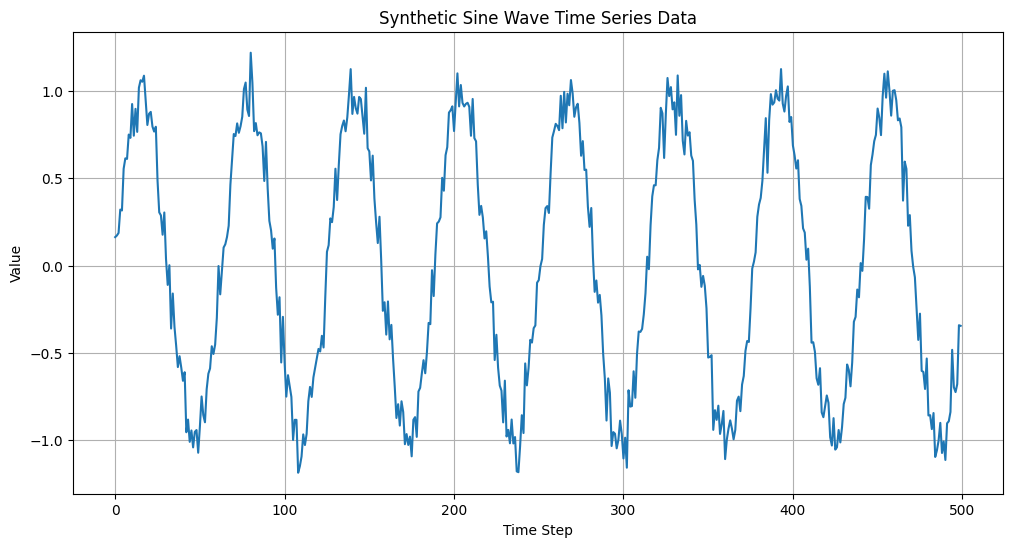


Original time series length: 500
RNN Input (X_rnn) shape: (490, 10, 1) (samples, timesteps, features)
RNN Output (y_rnn) shape: (490,)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Generate a synthetic time series (sine wave)
seq_length = 500
time = np.arange(0, seq_length)
data = np.sin(time / 10.0) + np.random.normal(0, 0.1, seq_length)

# Visualize the generated time series
plt.figure(figsize=(12, 6))
plt.plot(time, data)
plt.title('Synthetic Sine Wave Time Series Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True)
plt.show()

# Prepare data for RNN (create sequences for forecasting)
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:(i + n_steps)])
        y.append(data[i + n_steps])
    return np.array(X), np.array(y)

n_steps = 10 # Number of previous time steps to use for prediction
X_rnn, y_rnn = create_sequences(data, n_steps)

# Reshape X for RNN input: (samples, timesteps, features)
X_rnn = X_rnn.reshape((X_rnn.shape[0], X_rnn.shape[1], 1))

print(f"\nOriginal time series length: {seq_length}")
print(f"RNN Input (X_rnn) shape: {X_rnn.shape} (samples, timesteps, features)")
print(f"RNN Output (y_rnn) shape: {y_rnn.shape}")

# Split into training and testing sets
train_size = int(len(X_rnn) * 0.8)
X_train_rnn, X_test_rnn = X_rnn[:train_size], X_rnn[train_size:]
y_train_rnn, y_test_rnn = y_rnn[:train_size], y_rnn[train_size:]

Now, let's build and train a simple Recurrent Neural Network (RNN) model for time series forecasting.


SimpleRNN model built and compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)


Training SimpleRNN model...
SimpleRNN model training complete.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

RNN Mean Squared Error on test set: 0.0141


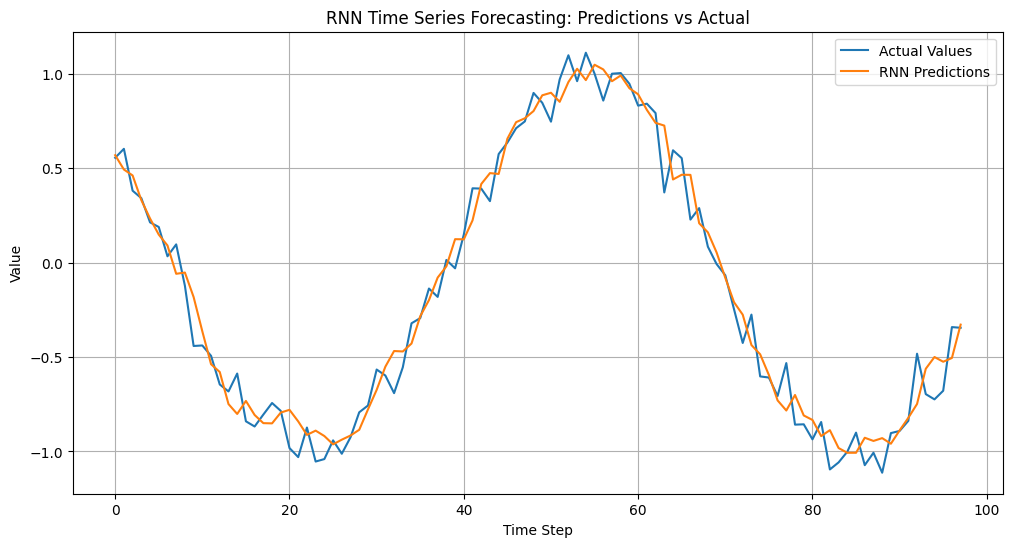

In [24]:
# Build the SimpleRNN model
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(n_steps, 1)),
    Dense(1)
])

# Compile the model
rnn_model.compile(optimizer='adam', loss='mse')

print("\nSimpleRNN model built and compiled.")
rnn_model.summary()

# Train the model
print("\nTraining SimpleRNN model...")
history = rnn_model.fit(X_train_rnn, y_train_rnn, epochs=20, batch_size=32, verbose=0)
print("SimpleRNN model training complete.")

# Make predictions on the test set
y_pred_rnn = rnn_model.predict(X_test_rnn)

# Evaluate the model
mse_rnn = mean_squared_error(y_test_rnn, y_pred_rnn)
print(f"\nRNN Mean Squared Error on test set: {mse_rnn:.4f}")

# Visualize predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_rnn, label='Actual Values')
plt.plot(y_pred_rnn, label='RNN Predictions')
plt.title('RNN Time Series Forecasting: Predictions vs Actual')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()